In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
%matplotlib inline 
sns.set(style="whitegrid")

## importing data 

In [2]:
df = pd.read_csv('Hotel Reservations.csv')
df

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50,0,Canceled


## Data Cleaning 

In [3]:
df.head(5)

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [5]:
df.describe().round(1)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,36275.0,36275.0,36275.0,36275.0,36275.0,36275.0,36275.0,36275.0,36275.0,36275.0,36275.0,36275.0,36275.0,36275.0
mean,1.8,0.1,0.8,2.2,0.0,85.2,2017.8,7.4,15.6,0.0,0.0,0.2,103.4,0.6
std,0.5,0.4,0.9,1.4,0.2,85.9,0.4,3.1,8.7,0.2,0.4,1.8,35.1,0.8
min,0.0,0.0,0.0,0.0,0.0,0.0,2017.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
25%,2.0,0.0,0.0,1.0,0.0,17.0,2018.0,5.0,8.0,0.0,0.0,0.0,80.3,0.0
50%,2.0,0.0,1.0,2.0,0.0,57.0,2018.0,8.0,16.0,0.0,0.0,0.0,99.4,0.0
75%,2.0,0.0,2.0,3.0,0.0,126.0,2018.0,10.0,23.0,0.0,0.0,0.0,120.0,1.0
max,4.0,10.0,7.0,17.0,1.0,443.0,2018.0,12.0,31.0,1.0,13.0,58.0,540.0,5.0


In [6]:
df.isna().sum()

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [9]:
df['type_of_meal_plan'].value_counts()

type_of_meal_plan
Meal Plan 1     27835
Not Selected     5130
Meal Plan 2      3305
Meal Plan 3         5
Name: count, dtype: int64

In [10]:
df['required_car_parking_space'] = df['required_car_parking_space'].replace(1,'Yes').replace(0,'No')

In [11]:
df['required_car_parking_space'].value_counts()

required_car_parking_space
No     35151
Yes     1124
Name: count, dtype: int64

In [12]:
df.rename(columns= {'arrival_year': 'year' , 'arrival_month':'month' , 'arrival_date':'day'},inplace= True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  object 
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   year                                  36275 non-null  int64  
 10  month                                 36275 non-null  int64  
 11  day            

In [14]:
df['date'] = pd.to_datetime(df[['year','month','day']] , errors='coerce')

In [15]:
df['date'].isna().sum()

np.int64(37)

In [16]:
df[df['date'].isna()]

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,year,month,day,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,date
2626,INN02627,2,0,1,5,Meal Plan 1,No,Room_Type 1,104,2018,2,29,Online,1,1,0,61.43,0,Canceled,NaT
3677,INN03678,1,0,1,3,Meal Plan 1,No,Room_Type 1,21,2018,2,29,Online,0,0,0,102.05,0,Canceled,NaT
5600,INN05601,2,0,1,3,Meal Plan 1,No,Room_Type 1,24,2018,2,29,Offline,0,0,0,45.50,0,Not_Canceled,NaT
6343,INN06344,1,0,1,1,Meal Plan 1,No,Room_Type 1,117,2018,2,29,Offline,0,0,0,76.00,0,Not_Canceled,NaT
7648,INN07649,2,1,1,5,Meal Plan 1,No,Room_Type 1,35,2018,2,29,Online,0,0,0,98.10,1,Canceled,NaT
8000,INN08001,2,2,1,3,Meal Plan 1,No,Room_Type 6,3,2018,2,29,Online,0,0,0,183.00,1,Not_Canceled,NaT
8989,INN08990,1,0,1,2,Meal Plan 1,No,Room_Type 1,117,2018,2,29,Offline,0,0,0,76.00,0,Not_Canceled,NaT
9153,INN09154,2,2,1,3,Meal Plan 1,No,Room_Type 6,3,2018,2,29,Online,0,0,0,189.75,0,Not_Canceled,NaT
9245,INN09246,2,0,1,3,Meal Plan 1,No,Room_Type 4,15,2018,2,29,Online,0,0,0,85.55,1,Not_Canceled,NaT
9664,INN09665,1,0,1,0,Meal Plan 1,No,Room_Type 4,21,2018,2,29,Online,0,0,0,117.00,0,Not_Canceled,NaT


In [17]:
df[df['date'].isna()].tail()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,year,month,day,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,date
30632,INN30633,3,0,1,2,Meal Plan 2,No,Room_Type 4,7,2018,2,29,Online,0,0,0,193.0,2,Not_Canceled,NaT
30839,INN30840,1,0,1,2,Meal Plan 1,No,Room_Type 1,117,2018,2,29,Offline,0,0,0,76.0,0,Not_Canceled,NaT
32041,INN32042,2,0,1,0,Not Selected,No,Room_Type 1,50,2018,2,29,Online,0,0,0,76.5,0,Canceled,NaT
34638,INN34639,1,0,1,2,Meal Plan 1,No,Room_Type 1,3,2018,2,29,Corporate,1,0,1,66.0,0,Not_Canceled,NaT
35481,INN35482,1,0,1,1,Meal Plan 1,No,Room_Type 1,7,2018,2,29,Corporate,0,0,0,66.0,0,Not_Canceled,NaT


In [18]:
# يوم 29 شهر 2 والسنه مش كبيسه كده التاريخ دا غلط نعدله ل 28 

In [19]:
mask = (df['month'] == 2) & (df['day'] == 29)
df.loc[mask, 'day'] = 28

In [20]:
df = df.drop(columns=['date'])

In [21]:
df['date'] = pd.to_datetime(df[['year','month','day']] , errors='coerce')

In [22]:
df['date'].isna().sum()

np.int64(0)

In [23]:
df['repeated_guest'].value_counts()

repeated_guest
0    35345
1      930
Name: count, dtype: int64

In [24]:
df['repeated_guest'] = df['repeated_guest'].replace(0,'No').replace(1,'Yes')

In [25]:
df['repeated_guest'].value_counts()

repeated_guest
No     35345
Yes      930
Name: count, dtype: int64

In [26]:
df['booking_status'].value_counts()

booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64

In [27]:
df

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,year,month,day,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,date
0,INN00001,2,0,1,2,Meal Plan 1,No,Room_Type 1,224,2017,10,2,Offline,No,0,0,65.00,0,Not_Canceled,2017-10-02
1,INN00002,2,0,2,3,Not Selected,No,Room_Type 1,5,2018,11,6,Online,No,0,0,106.68,1,Not_Canceled,2018-11-06
2,INN00003,1,0,2,1,Meal Plan 1,No,Room_Type 1,1,2018,2,28,Online,No,0,0,60.00,0,Canceled,2018-02-28
3,INN00004,2,0,0,2,Meal Plan 1,No,Room_Type 1,211,2018,5,20,Online,No,0,0,100.00,0,Canceled,2018-05-20
4,INN00005,2,0,1,1,Not Selected,No,Room_Type 1,48,2018,4,11,Online,No,0,0,94.50,0,Canceled,2018-04-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36270,INN36271,3,0,2,6,Meal Plan 1,No,Room_Type 4,85,2018,8,3,Online,No,0,0,167.80,1,Not_Canceled,2018-08-03
36271,INN36272,2,0,1,3,Meal Plan 1,No,Room_Type 1,228,2018,10,17,Online,No,0,0,90.95,2,Canceled,2018-10-17
36272,INN36273,2,0,2,6,Meal Plan 1,No,Room_Type 1,148,2018,7,1,Online,No,0,0,98.39,2,Not_Canceled,2018-07-01
36273,INN36274,2,0,0,3,Not Selected,No,Room_Type 1,63,2018,4,21,Online,No,0,0,94.50,0,Canceled,2018-04-21


## EDA

In [29]:
num_adults = sum(df['no_of_adults'])
num_adults

66926

In [30]:
num_children = sum(df['no_of_children'])
num_children

3819

In [35]:
adults_with_childrens = df[df['no_of_children']>0]['no_of_adults'].sum()
adults_with_childrens

np.int64(5000)

### Type of male distribution

In [36]:
df.groupby('type_of_meal_plan')['Booking_ID'].count()

type_of_meal_plan
Meal Plan 1     27835
Meal Plan 2      3305
Meal Plan 3         5
Not Selected     5130
Name: Booking_ID, dtype: int64

In [49]:
df.groupby('type_of_meal_plan').agg({'no_of_weekend_nights':'sum' ,'no_of_week_nights':'sum'})

,no_of_weekend_nights,no_of_week_nights
type_of_meal_plan,,
Meal Plan 1,23158,63261
Meal Plan 2,2246,6668
Meal Plan 3,1,8
Not Selected,4004,10024


### Number of guests who required car parking

In [50]:
df.groupby('required_car_parking_space')['Booking_ID'].count()

required_car_parking_space
No     35151
Yes     1124
Name: Booking_ID, dtype: int64

### Analysis of Room Types: Popularity, Pricing, and Booking Lead Time

In [58]:
room_analysis = df.groupby('room_type_reserved').agg({
    'Booking_ID':'count',
    'lead_time':'mean',
    'avg_price_per_room':'mean'
})
room_analysis.columns = ['Booking_num' , 'AVG_lead_time ' , 'AVG_Price']
room_analysis.round(2).sort_values('AVG_Price' , ascending= False)

,Booking_num,AVG_lead_time,AVG_Price
room_type_reserved,,,
Room_Type 6,966,61.02,182.21
Room_Type 7,158,37.09,155.20
Room_Type 4,6057,69.21,125.29
Room_Type 5,265,59.55,123.73
Room_Type 1,28130,89.64,95.92
Room_Type 2,692,101.02,87.85
Room_Type 3,7,69.57,73.68


### Yearly Sales Performance: Total Bookings and Revenue per Year

In [60]:
df.groupby('year').agg({
    'Booking_ID':'count',
    'avg_price_per_room':'sum'
})

,Booking_ID,avg_price_per_room
year,,
2017,6514,586441.73
2018,29761,3165247.15


### Market Segment Performance : Total Booking and Revenue per market 

In [63]:
df.groupby('market_segment_type').agg({
    'Booking_ID':'count',
    'avg_price_per_room':'sum'
}).sort_values('Booking_ID',ascending=False)

,Booking_ID,avg_price_per_room
market_segment_type,,
Online,23214,2605930.63
Offline,10528,964708.84
Corporate,2017,167232.98
Complementary,391,1228.43
Aviation,125,12588.00


### Booking Performance 

In [71]:
df.groupby('booking_status')['Booking_ID'].count()

booking_status
Canceled        11885
Not_Canceled    24390
Name: Booking_ID, dtype: int64

### Repeated Guest Analysis: Booking Patterns and Cancellation Rates (New vs. Returning)

In [79]:
df.groupby('repeated_guest').agg({
    'Booking_ID':'count',
    'no_of_previous_cancellations':'sum',
    'no_of_previous_bookings_not_canceled':'sum',
    'no_of_special_requests':'sum'
})

,Booking_ID,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,no_of_special_requests
repeated_guest,,,,
No,35345,0,0,21955
Yes,930,847,5565,523


### Loyalty Metrics: Past Cancellations vs. Successful Stays for Current Guests

In [81]:
confirmed_bookings = df[df['booking_status'] == 'Not_Canceled']
loyalty_analysis = confirmed_bookings.groupby('repeated_guest').agg({
    'Booking_ID':'count',
    'no_of_previous_cancellations':'sum',
    'no_of_previous_bookings_not_canceled':'sum',
    'no_of_special_requests':'sum'
})
loyalty_analysis.columns = ['NUM OF Booking' , 'Cancellations Booking' , 'Confirmed Booking','NUM OF Special Requests' ]
loyalty_analysis

,NUM OF Booking,Cancellations Booking,Confirmed Booking,NUM OF Special Requests
repeated_guest,,,,
No,23476,0,0,17978
Yes,914,781,5539,523


In [82]:
df.loc[:, 'is_canceled'] = df['booking_status'].apply(lambda x: 1 if x == 'Canceled' else 0)

In [83]:
df.loc[:, 'total_stay_nights'] = df['no_of_week_nights'] + df['no_of_weekend_nights']

In [84]:
df.loc[:, 'revenue'] = df['total_stay_nights'] * df['avg_price_per_room']

### Cancellation Rate by Market Segment

In [92]:
(df.groupby('market_segment_type')['is_canceled'].mean()*100).round(2).sort_values(ascending=False)

market_segment_type
Online           36.51
Offline          29.95
Aviation         29.60
Corporate        10.91
Complementary     0.00
Name: is_canceled, dtype: float64

### Calncellation Rate by month

In [93]:
(df.groupby('month')['is_canceled'].mean()*100).round(2)

month
1      2.37
2     25.23
3     29.69
4     36.37
5     36.49
6     40.31
7     45.00
8     39.02
9     33.36
10    35.36
11    29.36
12    13.31
Name: is_canceled, dtype: float64

### Revenue Per month

In [96]:
df.groupby('month')['revenue'].sum().round(1).sort_values(ascending = False)

month
10    1605314.1
9     1557440.0
8     1383366.6
7     1073278.2
6      990302.4
12     902368.4
5      874478.4
4      835756.9
11     828055.2
3      684619.9
2      401315.1
1      210983.5
Name: revenue, dtype: float64

### Cancellation Rate Per Special Requests

In [97]:
(df.groupby('no_of_special_requests')['is_canceled'].mean()*100).round(2)

no_of_special_requests
0    43.21
1    23.77
2    14.60
3     0.00
4     0.00
5     0.00
Name: is_canceled, dtype: float64

### Avg lead Time per Booking Status 

In [101]:
df.groupby('booking_status')['lead_time'].mean().round(2)

booking_status
Canceled        139.22
Not_Canceled     58.93
Name: lead_time, dtype: float64

### Total Revenue by Room Type for Confirmed Bookings

In [112]:
confirmed = df[df['booking_status'] == 'Not_Canceled']
room_revenue = confirmed.groupby('room_type_reserved')['revenue'].sum().sort_values(ascending = False)
room_revenue

room_type_reserved
Room_Type 1    4934054.51
Room_Type 4    1593929.60
Room_Type 6     282425.77
Room_Type 2     122324.28
Room_Type 5      63785.63
Room_Type 7      53469.88
Room_Type 3       1115.00
Name: revenue, dtype: float64

### Comparative Analysis: Online Segment vs. Other Market Segments (Confirmed Booking)

In [117]:
confirmed.groupby('market_segment_type').agg({
    'revenue':'sum',
    'lead_time':'mean'
}).round(2)

,revenue,lead_time
market_segment_type,,
Aviation,25240.00,4.60
Complementary,2778.99,12.04
Corporate,275493.91,17.66
Offline,1855433.18,85.75
Online,4892158.59,52.11


### Data Visualization 

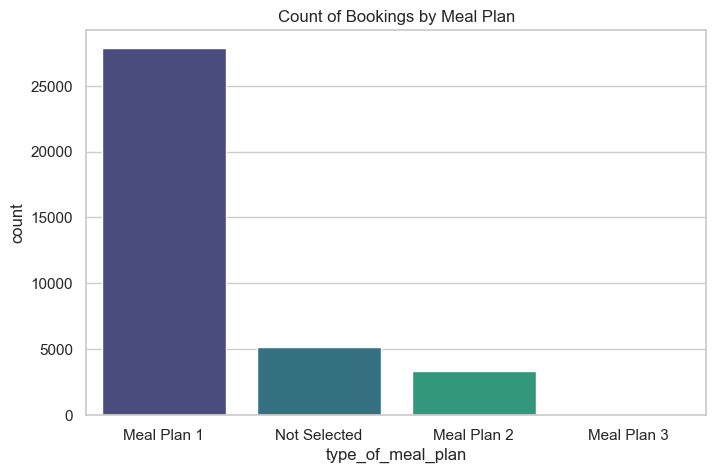

In [121]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='type_of_meal_plan', hue='type_of_meal_plan', palette='viridis', legend=False)
plt.title('Count of Bookings by Meal Plan')
plt.show()

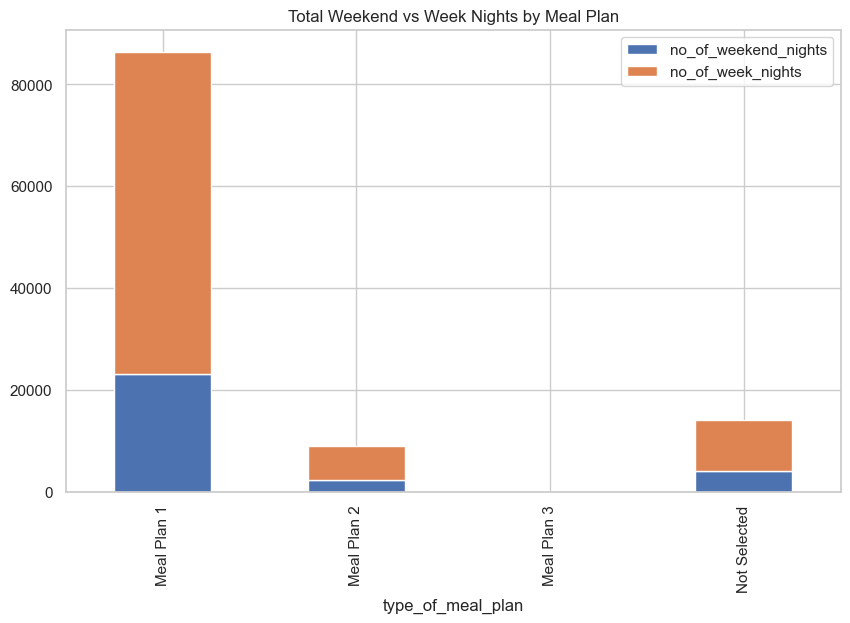

In [122]:
meal_nights = df.groupby('type_of_meal_plan').agg({'no_of_weekend_nights':'sum' ,'no_of_week_nights':'sum'})
meal_nights.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Total Weekend vs Week Nights by Meal Plan')
plt.show()

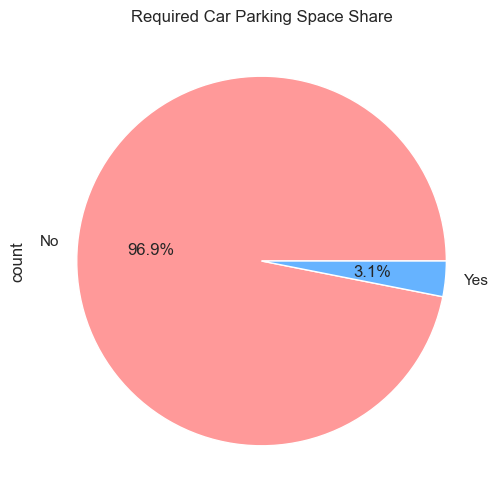

In [123]:
plt.figure(figsize=(6,6))
df['required_car_parking_space'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Required Car Parking Space Share')
plt.show()

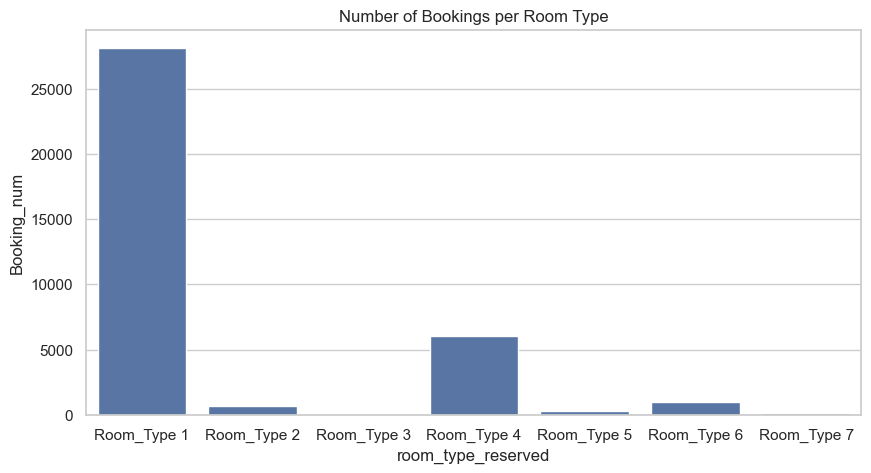

In [124]:
plt.figure(figsize=(10,5))
sns.barplot(x=room_analysis.index, y='Booking_num', data=room_analysis)
plt.title('Number of Bookings per Room Type')
plt.show()

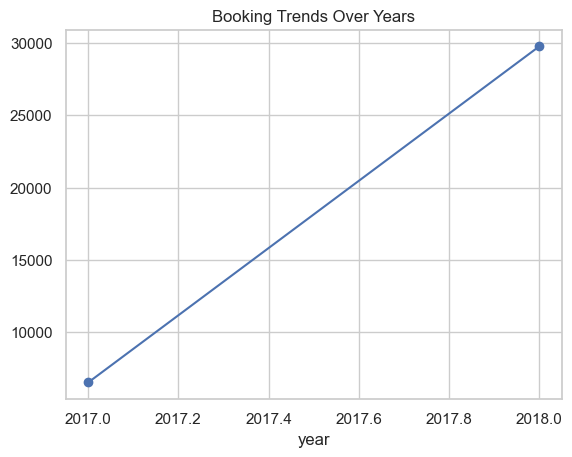

In [125]:
year_data = df.groupby('year').agg({'Booking_ID':'count', 'avg_price_per_room':'sum'})
year_data['Booking_ID'].plot(kind='line', marker='o', title='Booking Trends Over Years')
plt.show()

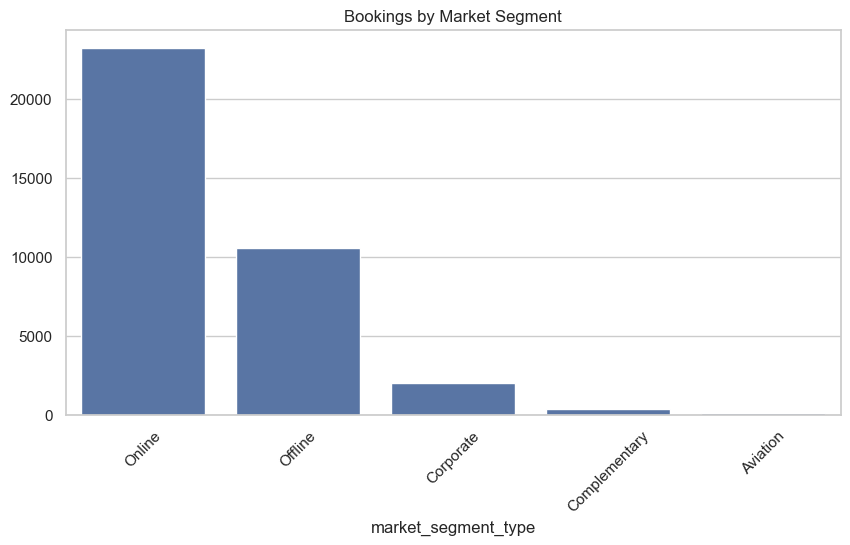

In [126]:
market_data = df.groupby('market_segment_type')['Booking_ID'].count().sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=market_data.index, y=market_data.values)
plt.xticks(rotation=45)
plt.title('Bookings by Market Segment')
plt.show()

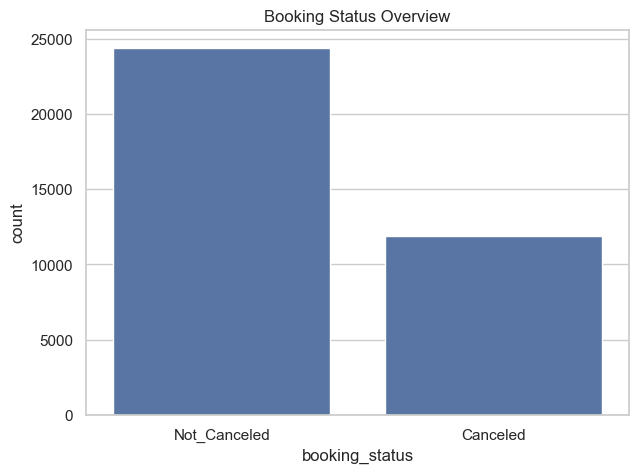

In [127]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='booking_status')
plt.title('Booking Status Overview')
plt.show()

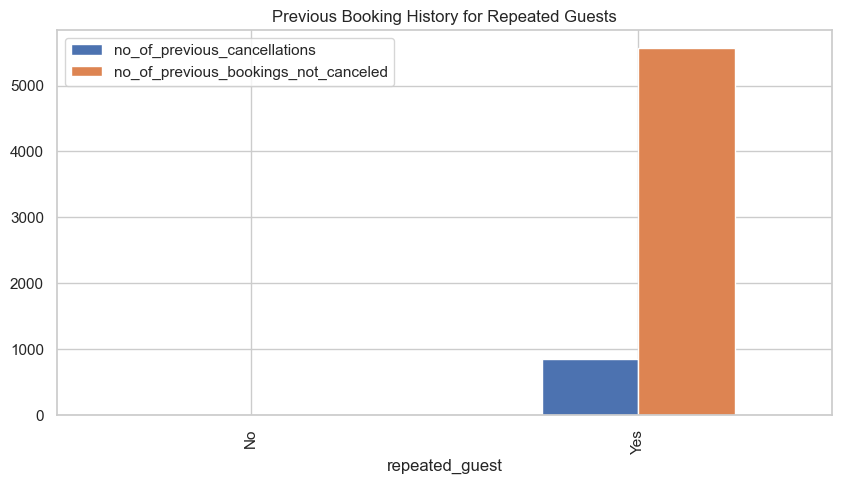

In [128]:
guest_analysis = df.groupby('repeated_guest')[['no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled']].sum()
guest_analysis.plot(kind='bar', figsize=(10,5))
plt.title('Previous Booking History for Repeated Guests')
plt.show()

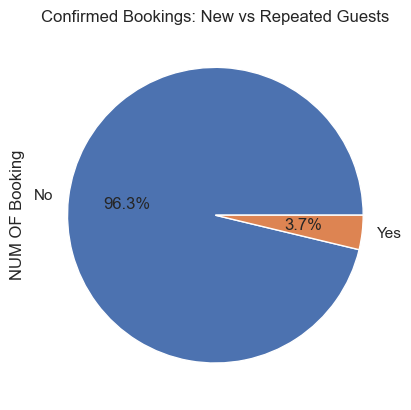

In [129]:
loyalty_analysis['NUM OF Booking'].plot(kind='pie', autopct='%1.1f%%', title='Confirmed Bookings: New vs Repeated Guests')
plt.show()

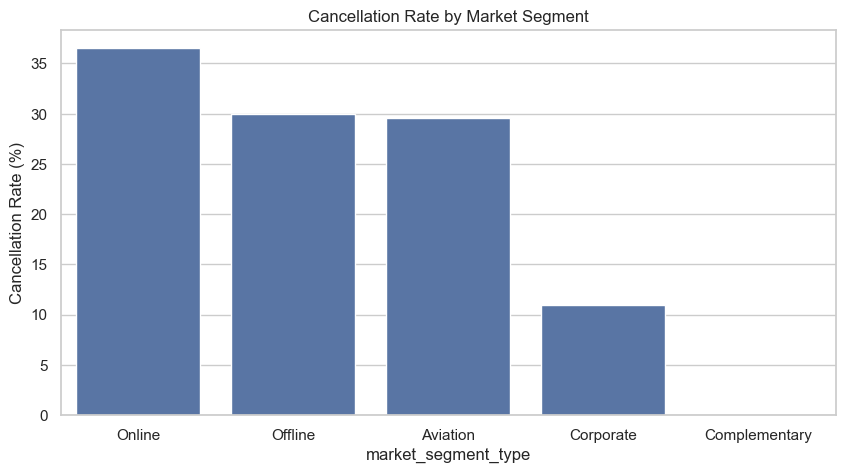

In [130]:
cancel_rate = (df.groupby('market_segment_type')['is_canceled'].mean()*100).sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=cancel_rate.index, y=cancel_rate.values)
plt.ylabel('Cancellation Rate (%)')
plt.title('Cancellation Rate by Market Segment')
plt.show()

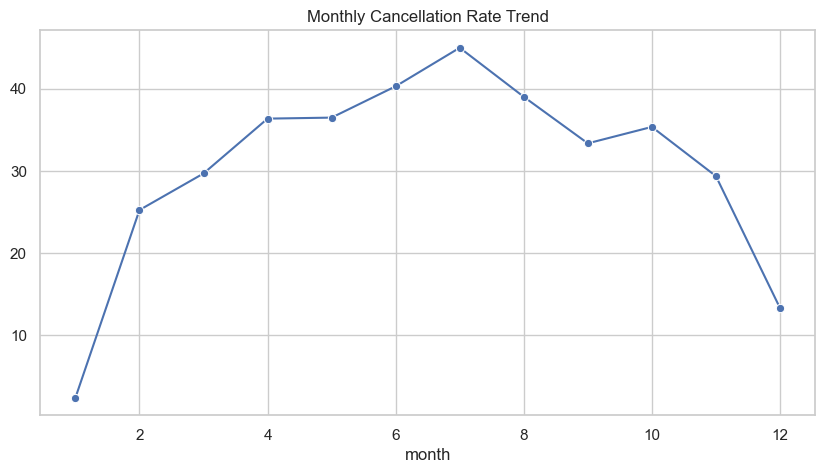

In [131]:
month_cancel = (df.groupby('month')['is_canceled'].mean()*100)
plt.figure(figsize=(10,5))
sns.lineplot(x=month_cancel.index, y=month_cancel.values, marker='o')
plt.title('Monthly Cancellation Rate Trend')
plt.show()

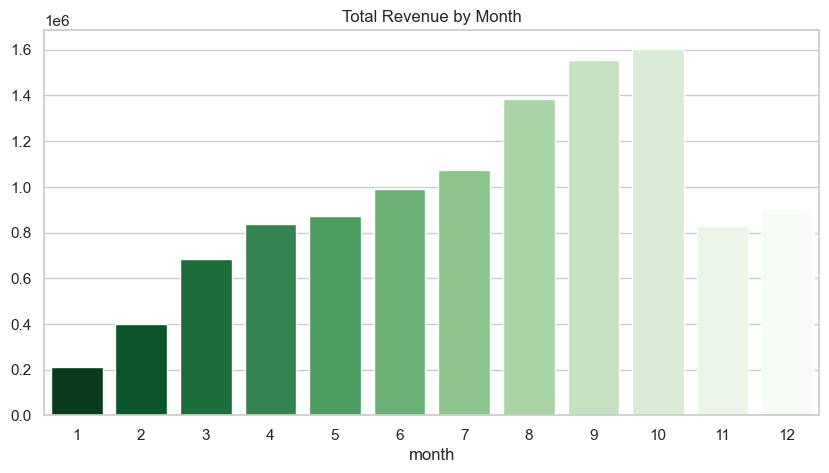

In [134]:
month_rev = df.groupby('month')['revenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(
    x=month_rev.index, 
    y=month_rev.values, 
    hue=month_rev.index,  
    palette='Greens_r', 
    legend=False         
)
plt.title('Total Revenue by Month')
plt.show()

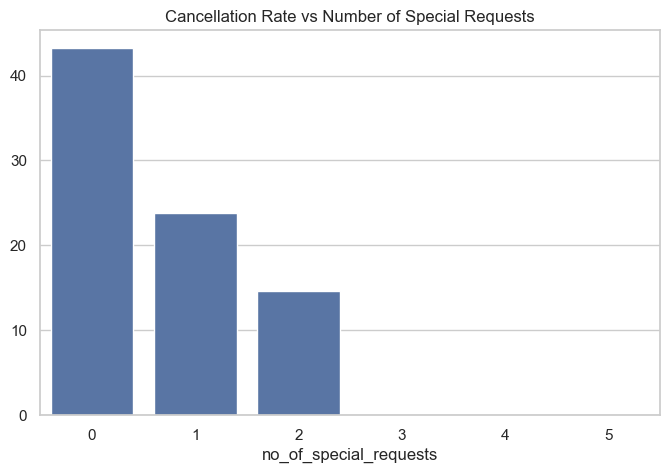

In [135]:
spec_cancel = (df.groupby('no_of_special_requests')['is_canceled'].mean()*100)
plt.figure(figsize=(8,5))
sns.barplot(x=spec_cancel.index, y=spec_cancel.values)
plt.title('Cancellation Rate vs Number of Special Requests')
plt.show()

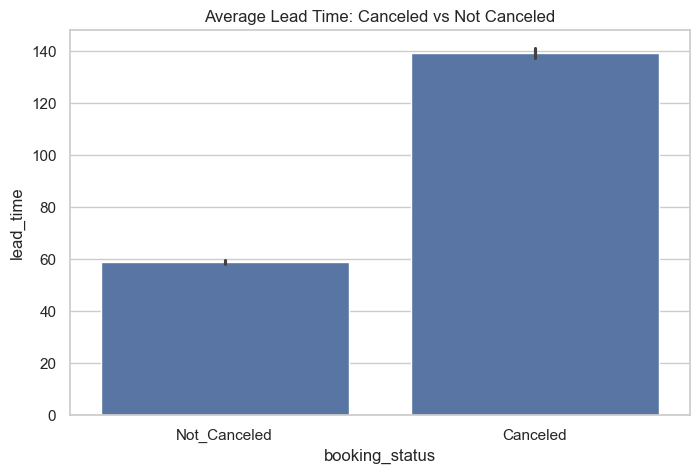

In [136]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='booking_status', y='lead_time', estimator='mean')
plt.title('Average Lead Time: Canceled vs Not Canceled')
plt.show()

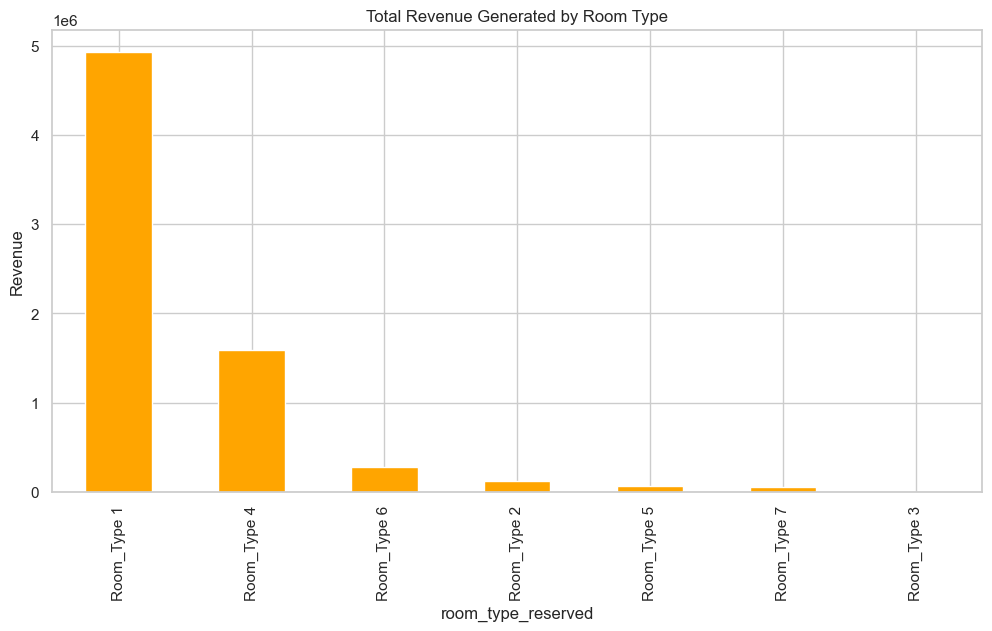

In [137]:
plt.figure(figsize=(12,6))
room_revenue.plot(kind='bar', color='orange')
plt.title('Total Revenue Generated by Room Type')
plt.ylabel('Revenue')
plt.show()

In [138]:
df.to_csv('clean_data')